In [7]:
import pandas as pd

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [8]:
df=pd.read_csv(r"C:\Users\ASUS\Desktop\Projects\Content_monetization_modeler\data\raw data\youtube_ad_revenue_dataset.csv")

In [9]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388
...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811


In [10]:
df.shape

(122400, 12)

In [11]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [12]:
df.duplicated().sum()

np.int64(2400)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [16]:
df['like_rate']=df['likes']/df['views']
df['comments _rate']=df['comments']/df['views']
df['watch_time_rate']=df['watch_time_minutes']/(df['video_length_minutes']*df['views'])

In [17]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,like_rate,comments _rate,watch_time_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.122886,0.032206,0.931748
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.064091,0.034541,0.063964
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.195999,0.018520,0.216719
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.118696,0.024118,0.265314
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.187886,0.048235,0.238726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,0.169796,0.014919,0.167529
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,0.168740,0.006220,0.350211
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,0.068180,NaN,0.112639
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,0.157812,0.010352,0.717548


In [18]:
distinct_cat=df['category'].unique()
distinct_cat.tolist()

['Entertainment', 'Gaming', 'Education', 'Music', 'Tech', 'Lifestyle']

In [19]:
cat_avg_rate_of_like_comment=[]
for cat in distinct_cat:
    avg_like_rate=df[df['category']==cat]['like_rate'].mean()
    avg_comment_rate=df[df['category']==cat]['comments _rate'].mean()
    cat_avg_rate_of_like_comment.append([cat,avg_like_rate,avg_comment_rate])
cat_avg_rate_of_like_comment

[['Entertainment',
  np.float64(0.10967184419983632),
  np.float64(0.027271499887900688)],
 ['Gaming', np.float64(0.11053261711391994), np.float64(0.027445679477982682)],
 ['Education',
  np.float64(0.11000936217585718),
  np.float64(0.027582488195781924)],
 ['Music', np.float64(0.11017536887468625), np.float64(0.027443003824229685)],
 ['Tech', np.float64(0.11003715098594091), np.float64(0.027465614954164514)],
 ['Lifestyle',
  np.float64(0.10934895922309819),
  np.float64(0.02740681657903375)]]

In [20]:
cat_avg_df = df.groupby('category')[['like_rate', 'comments _rate','watch_time_rate']].mean()

cat_avg_list = cat_avg_df.reset_index().values.tolist()   
cat_avg_list

[['Education', 0.11000936217585715, 0.027582488195781924, 0.3613209890928091],
 ['Entertainment',
  0.10967184419983632,
  0.02727149988790068,
  0.35890921074650783],
 ['Gaming', 0.11053261711391996, 0.027445679477982682, 0.3660581529334815],
 ['Lifestyle', 0.1093489592230982, 0.02740681657903375, 0.3633886217110437],
 ['Music', 0.11017536887468625, 0.027443003824229685, 0.360630059907934],
 ['Tech', 0.11003715098594091, 0.027465614954164514, 0.36757054381710036]]

In [21]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
like_rate               6000
comments _rate          6000
watch_time_rate         6000
dtype: int64

In [22]:

likes_map = {item[0]: item[1] for item in cat_avg_list}
comm_map  = {item[0]: item[2] for item in cat_avg_list}
watch_map = {item[0]: item[3] for item in cat_avg_list}

df['likes'] = df['likes'].fillna(df['category'].map(likes_map) * df['views'])

df['comments'] = df['comments'].fillna(df['category'].map(comm_map) * df['views'])

df['watch_time_minutes'] = df['watch_time_minutes'].fillna(df['category'].map(watch_map) * (df['views'] * df['video_length_minutes']))

In [23]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                      0
comments                   0
watch_time_minutes         0
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
like_rate               6000
comments _rate          6000
watch_time_rate         6000
dtype: int64

In [24]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,like_rate,comments _rate,watch_time_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.000000,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.122886,0.032206,0.931748
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.000000,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.064091,0.034541,0.063964
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.000000,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.195999,0.018520,0.216719
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.000000,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.118696,0.024118,0.265314
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.000000,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.187886,0.048235,0.238726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.000000,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,0.169796,0.014919,0.167529
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.000000,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,0.168740,0.006220,0.350211
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,281.989469,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,0.068180,NaN,0.112639
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.000000,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,0.157812,0.010352,0.717548


In [25]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                      0
comments                   0
watch_time_minutes         0
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
like_rate               6000
comments _rate          6000
watch_time_rate         6000
dtype: int64

In [26]:
df.drop(columns=['like_rate','comments _rate'], inplace=True)

In [27]:
df['watch_time_rate']=df['watch_time_rate'].fillna(df['watch_time_minutes']/df['video_length_minutes'])

In [81]:
df.isnull().sum()

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
watch_time_rate         0
dtype: int64

In [28]:
df.columns

Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'watch_time_rate'],
      dtype='object')

In [29]:
df["engagement_rate"]=((df["likes"]+df["comments"])/df["views"])*100

In [30]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,watch_time_rate,engagement_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.000000,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.931748,15.509259
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.000000,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.063964,9.863233
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.000000,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.216719,21.451916
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.000000,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.265314,14.281443
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.000000,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.238726,23.612094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.000000,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,0.167529,18.471532
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.000000,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,0.350211,17.496051
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,281.989469,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,0.112639,9.564522
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.000000,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,0.717548,16.816406


In [31]:
df["likes"]=df["likes"].astype('int64')
df["comments"]=df["comments"].astype('int64')

In [32]:
df.dtypes

video_id                 object
date                     object
views                     int64
likes                     int64
comments                  int64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
watch_time_rate         float64
engagement_rate         float64
dtype: object

In [33]:
df["device"]=df["device"].str.title()

In [24]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.214184,2.862137,228086,Entertainment,Tv,IN,203.178237,15.509259
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,9.863233
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.658498,26.200634,240534,Education,Tv,CA,360.134008,21.451916
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,14.281443
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,23.612094
...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673,147,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,18.471532
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709,63,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,17.496051
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700,281,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,9.563992
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616,106,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,16.816406


In [34]:
df.columns

Index(['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes',
       'video_length_minutes', 'subscribers', 'category', 'device', 'country',
       'ad_revenue_usd', 'watch_time_rate', 'engagement_rate'],
      dtype='object')

In [2]:
num_cont=['views', 'likes', 'comments', 'watch_time_minutes','video_length_minutes', 'subscribers','engagement_rate','watch_time_rate']
cat=['category', 'device', 'country']

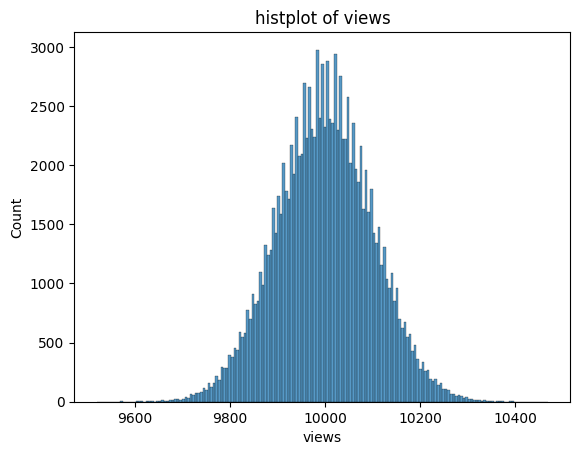

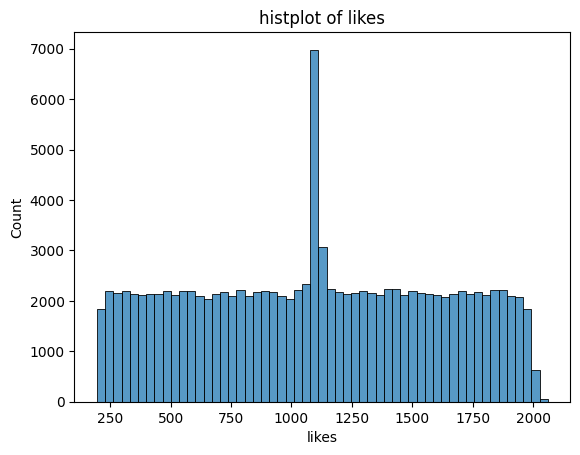

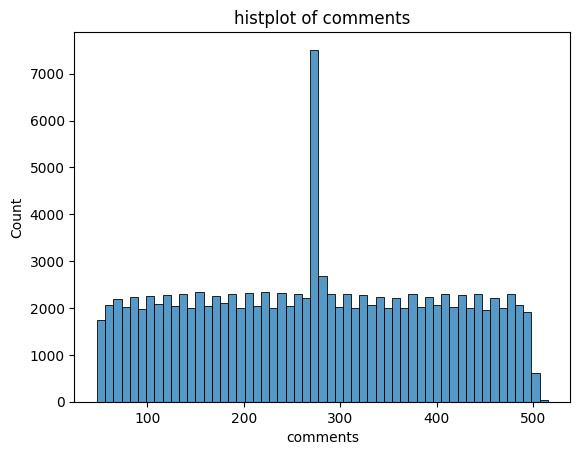

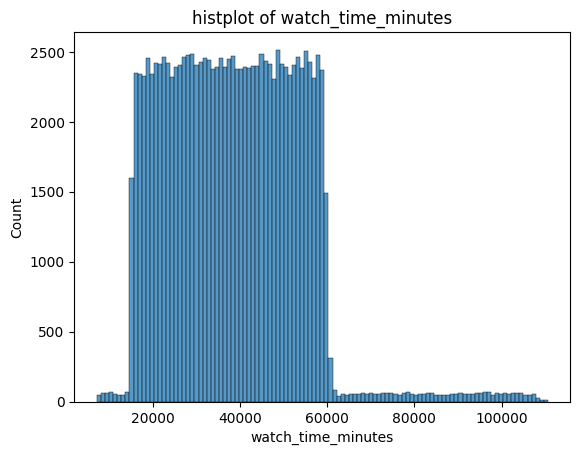

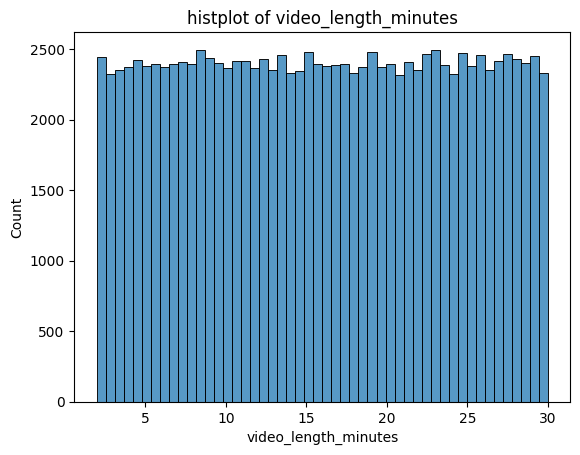

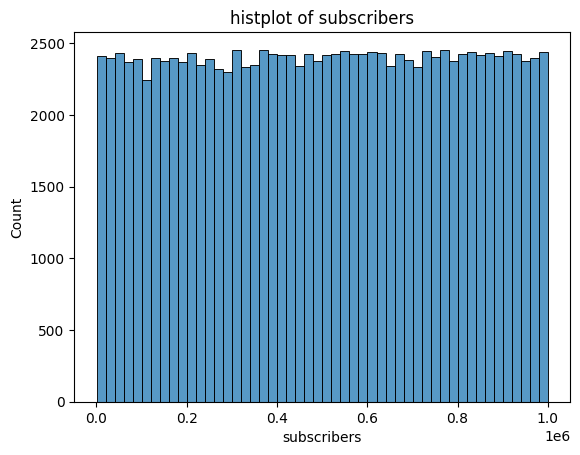

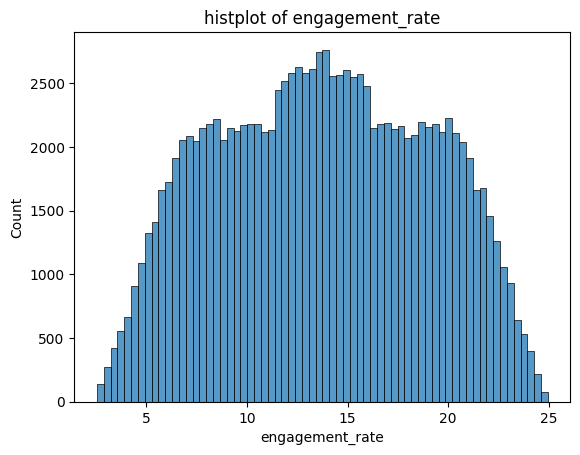

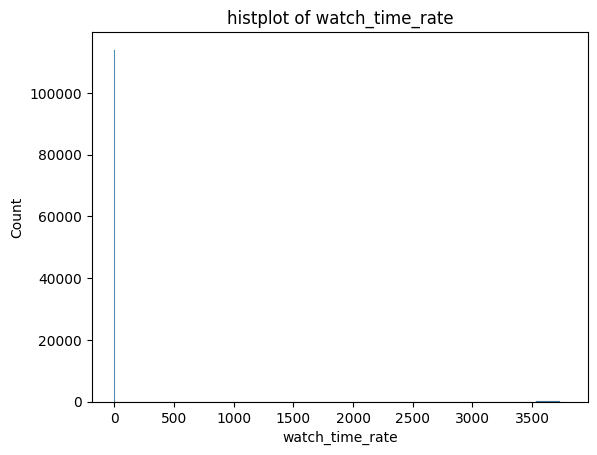

In [40]:
for col in num_cont:
    sns.histplot(df,x=df[col])
    plt.title(f"histplot of {col}")
    plt.xlabel(col)
    plt.show()

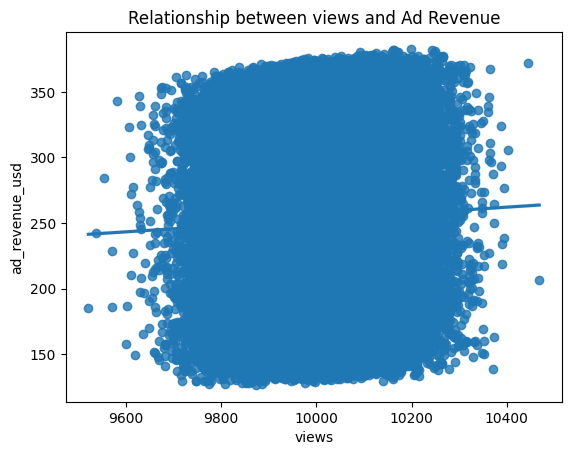

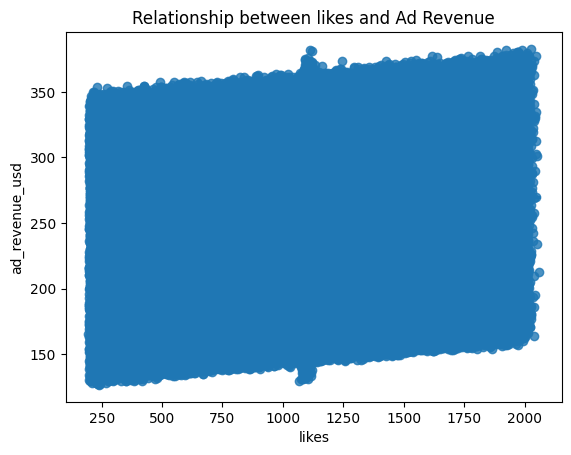

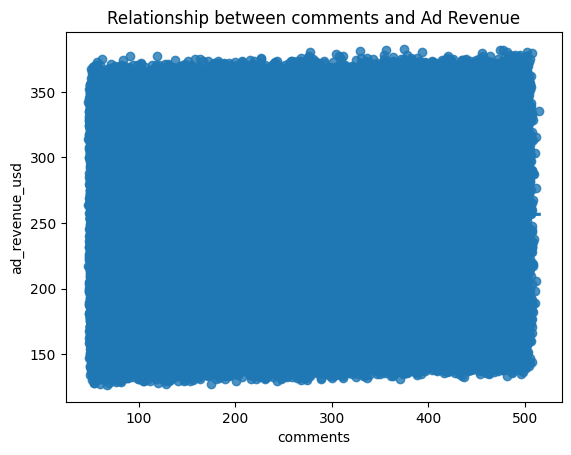

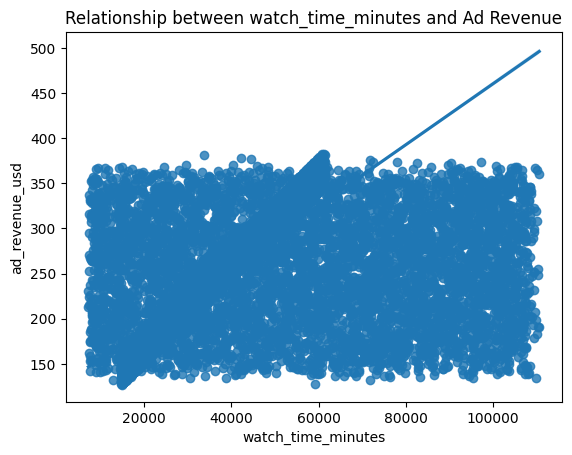

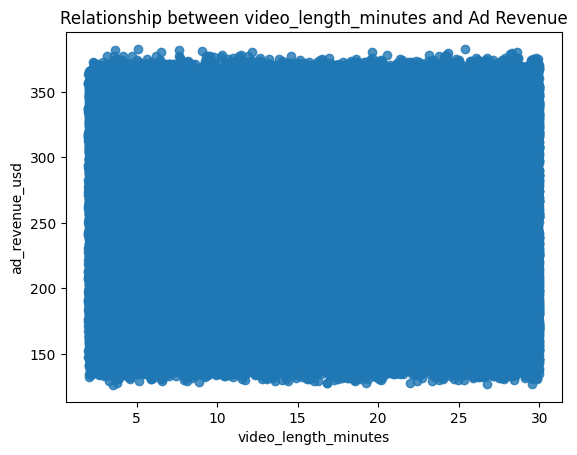

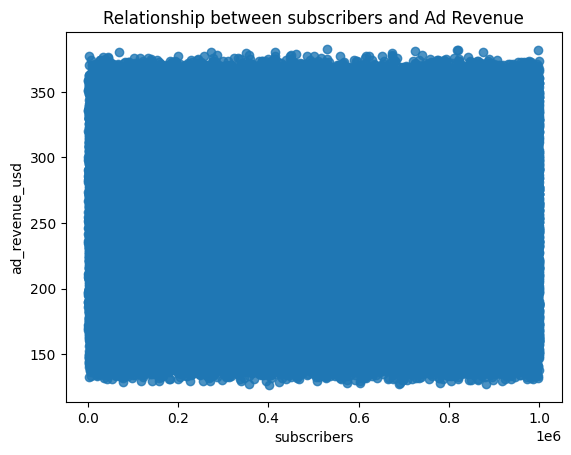

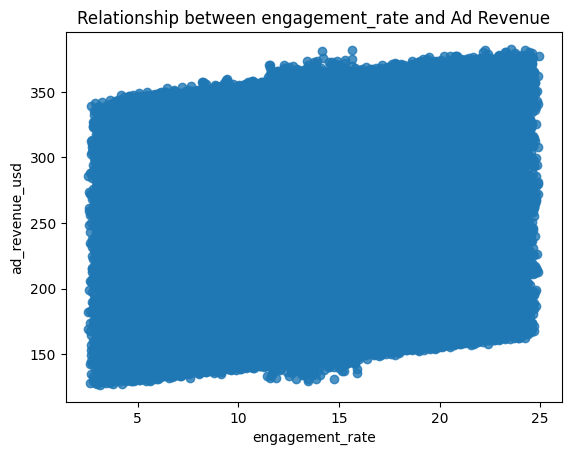

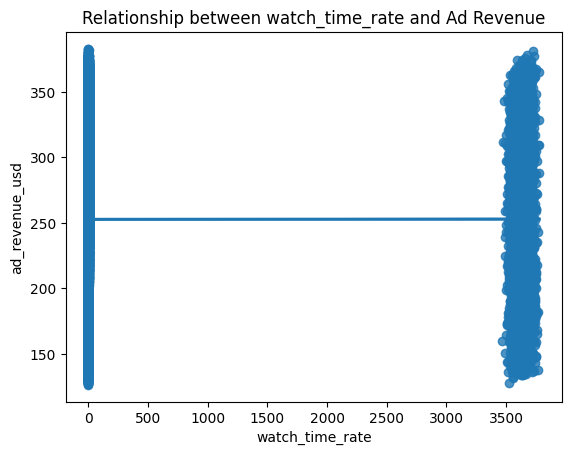

In [ ]:
for col in num_cont:
    sns.regplot(df,x=df[col],y=df["ad_revenue_usd"])
    plt.title(f"Relationship between {col} and Ad Revenue")
    plt.xlabel(col)
    plt.ylabel("ad_revenue_usd")
    plt.show()

In [36]:
for col in num_cont:
    correlation = df[col].corr(df['ad_revenue_usd'])
    print(f'{col} , Correlation: {correlation} ')

views , Correlation: 0.03794165856253056 
likes , Correlation: 0.14263230226590976 
comments , Correlation: 0.03366584670110503 
watch_time_minutes , Correlation: 0.8169370850666399 
video_length_minutes , Correlation: 0.0003640697690700728 
subscribers , Correlation: 0.0050649520569861365 
engagement_rate , Correlation: 0.1456258043963147 
watch_time_rate , Correlation: 0.0006397634421422359 


In [37]:
df

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,watch_time_rate,engagement_rate
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221,320,26497.214184,2.862137,228086,Entertainment,Tv,IN,203.178237,0.931748,15.509259
1,vid_3459,2024-09-22 10:50:40.993199,10017,642,346,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.063964,9.863233
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979,187,57332.658498,26.200634,240534,Education,Tv,CA,360.134008,0.216719,21.451916
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191,242,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,0.265314,14.281443
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858,477,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,0.238726,23.612094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673,147,42075.704885,25.490195,210818,Education,Tablet,US,280.986396,0.167529,18.471532
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709,63,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981,0.350211,17.496051
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700,281,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106,0.112639,9.564522
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616,106,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811,0.717548,16.816406


In [38]:
num_feat=['watch_time_minutes','engagement_rate']

In [44]:
cat=['category', 'device', 'country']

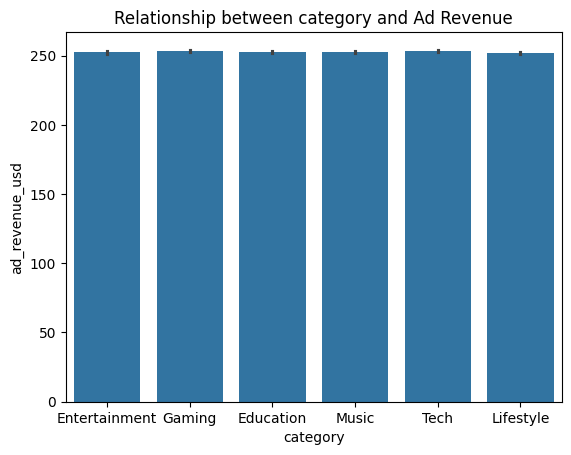

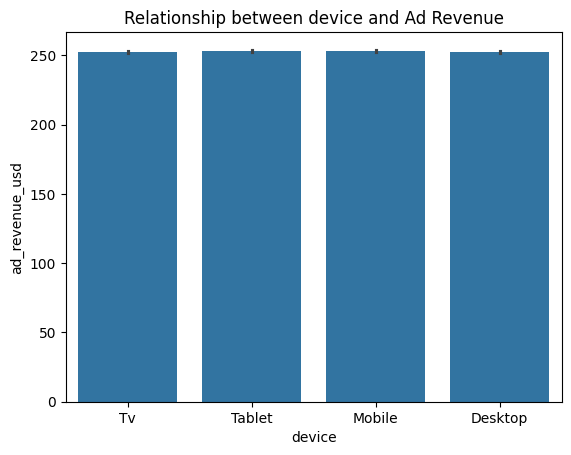

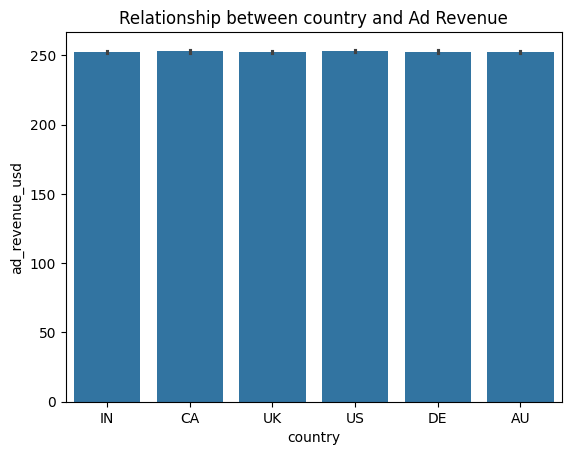

In [45]:
for col in cat:
    sns.barplot(df,x=df[col],y=df["ad_revenue_usd"])
    plt.title(f"Relationship between {col} and Ad Revenue")
    plt.xlabel(col)
    plt.ylabel("ad_revenue_usd")
    plt.show()

In [ ]:
from scipy import stats

In [ ]:
for col in cat:
    groups = [group_data["ad_revenue_usd"] for name, group_data in df.groupby(col)]
    print(groups)

[2         360.134008
4         165.514388
12        235.990773
14        177.994429
25        215.656397
             ...    
122368    317.691547
122371    196.990817
122373    312.107014
122389    331.209389
122395    280.986396
Name: ad_revenue_usd, Length: 20514, dtype: float64, 0         203.178237
3         224.638261
7         164.533455
8         336.409856
21        160.283965
             ...    
122363    196.227013
122364    228.010709
122369    231.937883
122378    266.711652
122381    199.164255
Name: ad_revenue_usd, Length: 20411, dtype: float64, 1         140.880508
10        330.219763
36        154.697810
41        349.579266
46        282.287786
             ...    
122386    200.963436
122388    174.706214
122390    352.939446
122393    342.350940
122394    211.544626
Name: ad_revenue_usd, Length: 20359, dtype: float64, 20        347.276222
22        188.201874
23        279.112097
42        161.228403
49        214.551197
             ...    
122332    330.638966


In [ ]:
for col in cat:

    groups = [data['ad_revenue_usd'] for name, data in df.groupby(col)]
    
  
    f_stat, p_value = stats.f_oneway(*groups)
    

    print(f"Checking {col}...")
    print(f"P-Value: {p_value}")
    
    if p_value < 0.05:
        print("Conclusion: This column MATTERS for revenue!")
    else:
        print("Conclusion: This column doesn't really affect revenue.")
    print("-" * 20)

Checking category...
P-Value: 0.05151003856953066
Conclusion: This column doesn't really affect revenue.
--------------------
Checking device...
P-Value: 0.12465354541651634
Conclusion: This column doesn't really affect revenue.
--------------------
Checking country...
P-Value: 0.8537863556054848
Conclusion: This column doesn't really affect revenue.
--------------------


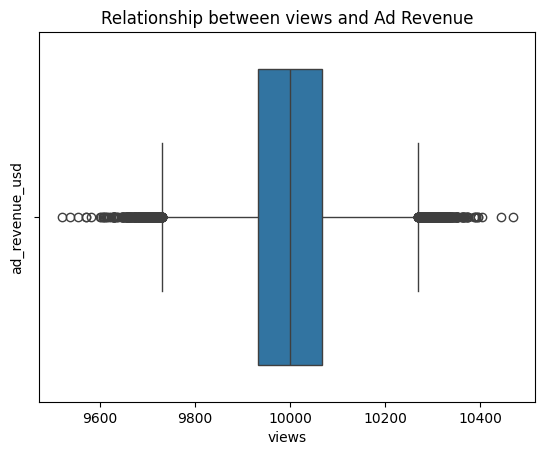

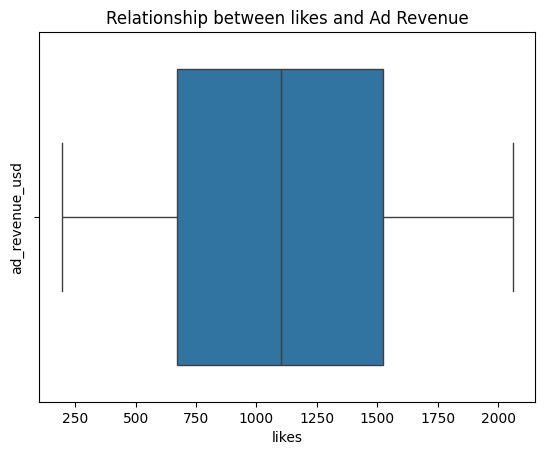

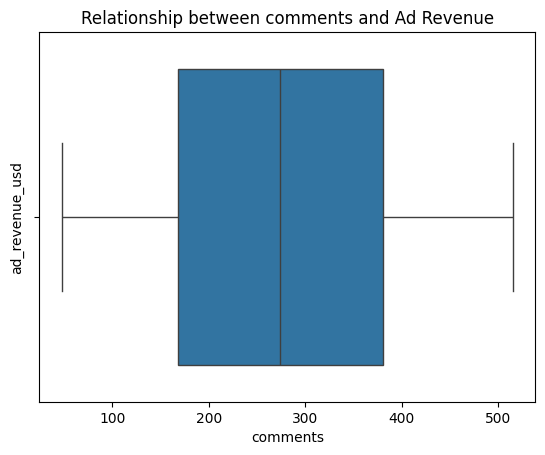

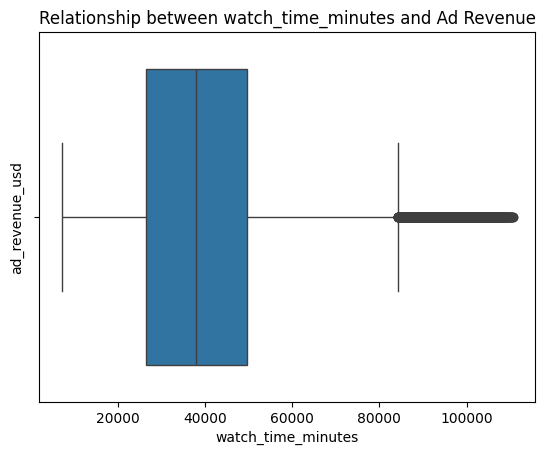

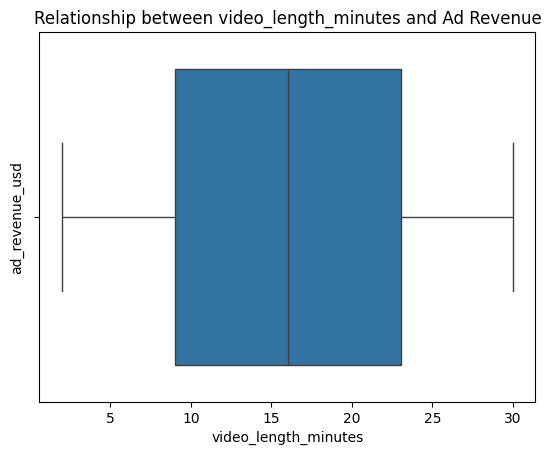

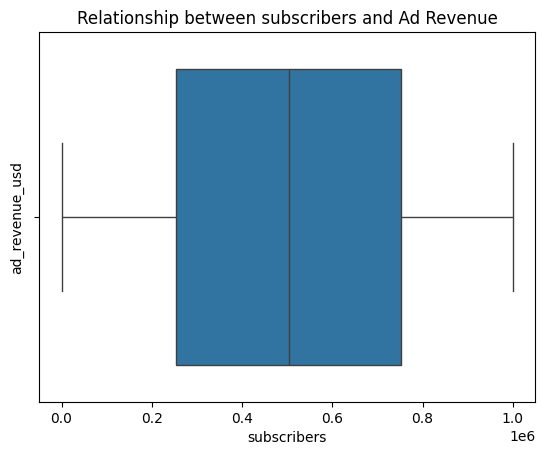

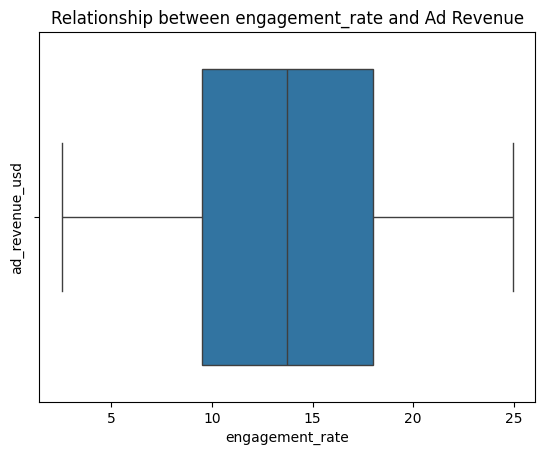

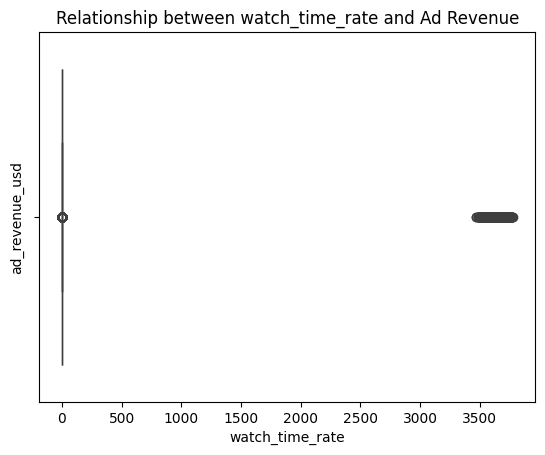

In [46]:
for col in num_cont:
    sns.boxplot(df,x=df[col])
    plt.title(f"Relationship between {col} and Ad Revenue")
    plt.xlabel(col)
    plt.ylabel("ad_revenue_usd")
    plt.show()

In [38]:
%pip install scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [39]:
%pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [33]:
cat_feat=['category']

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
import category_encoders as ce

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib
from sklearn.model_selection import GridSearchCV

num_feat = ['watch_time_minutes','engagement_rate']
cat_feat = ['category']

X = df[num_feat + cat_feat]
y = df['ad_revenue_usd']

# 2. Split (ensure the order: X_train, X_test, y_train, y_test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


preprocessor=ColumnTransformer(transformers=[('numeric',RobustScaler(),num_feat),('category',ce.BinaryEncoder(),cat_feat)])


# 1. Update Pipeline with a named 'poly' step
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures()), # New step
    ('LinearRegression', LinearRegression())
])

# 2. Define the Grid Search parameters
# Note: 'poly__degree' targets the 'degree' parameter of the 'poly' step
param_grid = {
    'poly__degree': [1, 2, 3, 4, 5, 6, 7],
    'poly__interaction_only': [True, False]
}

# 3. Initialize and Fit GridSearchCV
grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 4. Use the best model for predictions
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 5. Results
print(f"Best Degree: {grid_search.best_params_['poly__degree']}")
print(f"Confidence Score (R²): {r2_score(y_test, y_pred):.2f}")

Best Degree: 7
Confidence Score (R²): 0.90


In [102]:
model_pipeline

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('LinearRegression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [34]:
a = df[num_feat + cat_feat]
b = df['ad_revenue_usd']

In [35]:
a

,watch_time_minutes,likes,engagement_rate,category
0,26497.214184,1221,15.509259,Entertainment
1,15209.747445,642,9.863233,Gaming
2,57332.658498,1979,21.451916,Education
3,31334.517771,1191,14.281443,Entertainment
4,15665.666434,1858,23.612094,Education
...,...,...,...,...
122395,42075.704885,1673,18.471532,Education
122396,57563.703040,1709,17.496051,Music
122397,27549.714659,700,9.563992,Tech
122398,56967.384382,1616,16.816406,Music


In [36]:
b

0         203.178237
1         140.880508
2         360.134008
3         224.638261
4         165.514388
             ...    
122395    280.986396
122396    354.612981
122397    203.643106
122398    351.525811
122399    253.842824
Name: ad_revenue_usd, Length: 122400, dtype: float64

In [ ]:
num_feat = ['watch_time_minutes','engagement_rate']
cat_feat = ['category']

X = df[num_feat + cat_feat]
y = df['ad_revenue_usd']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




model_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('LinearRegression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [110]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred=model_pipeline.predict(X_test)

r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Confidence Score (R²): {r2:.2f}")
print(f"RMSE: {rmse:.1f}")               
print(f"MAE: {mae:.1f}") 

Confidence Score (R²): 0.70
RMSE: 33.9
MAE: 19.9


In [93]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
import category_encoders as ce

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib
from sklearn.model_selection import GridSearchCV

num_feat = ['watch_time_minutes','engagement_rate']
cat_feat = ['category']

X = df[num_feat + cat_feat]
y = df['ad_revenue_usd']

# 2. Split (ensure the order: X_train, X_test, y_train, y_test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor

preprocessor=ColumnTransformer(transformers=[('numeric',RobustScaler(),num_feat),('category',ce.BinaryEncoder(),cat_feat)])
model_pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])



param_grid = {
    'regressor__n_estimators': [100, 300 ,500],
    'regressor__max_depth': [10, 20,30],
    'regressor__min_samples_split': [2, 5,10],
    'regressor__max_features': ['sqrt','log2']
}

# 2. Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all your CPU cores to speed it up
grid_search_rf = GridSearchCV(
    estimator=model_pipeline2, 
    param_grid=param_grid,
    cv=5,
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

# 3. Fit to training data
grid_search_rf.fit(X_train, y_train)

# 4. Get the best model and evaluate
best_rf_model = grid_search_rf.best_estimator_
y_pred = best_rf_model.predict(X_test)


Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [94]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred=best_rf_model.predict(X_test)

r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Confidence Score (R²): {r2:.2f}")
print(f"RMSE: {rmse:.1f}")               
print(f"MAE: {mae:.1f}") 

Confidence Score (R²): 0.92
RMSE: 17.3
MAE: 5.3


In [70]:
y_pred = model_pipeline2.predict(X_test)

# 2. Create a comparison DataFrame
test_results = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred
})

# 3. Calculate the absolute error for each video
test_results['Difference ($)'] = (test_results['Actual Revenue'] - test_results['Predicted Revenue']).abs()

# 4. View the first 10 'tests'
print("Testing Model on y_test (Top 10 Rows):")
print(test_results.head(10))

# Verify the overall Average Error
print(f"\nOverall Mean Absolute Error: ${test_results['Difference ($)'].mean():.2f}")

Testing Model on y_test (Top 10 Rows):
   Actual Revenue  Predicted Revenue  Difference ($)
0      352.853521         353.164995        0.311474
1      341.983788         338.499371        3.484417
2      204.586883         209.007877        4.420994
3      176.835670         176.549122        0.286548
4      270.842839         269.728080        1.114759
5      287.477455         287.846315        0.368860
6      259.938374         255.892216        4.046158
7      261.089317         266.057684        4.968367
8      275.035544         275.208125        0.172581
9      307.006351         306.422918        0.583433

Overall Mean Absolute Error: $4.57


In [95]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# 1. Your existing pipeline
model_pipeline3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42)) # Removed static params to tune them
])

# 2. Define the parameter grid (use 'regressor__' prefix)
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 10],
    'regressor__min_samples_split': [5, 10]
}

# 3. Initialize GridSearchCV
grid_search = GridSearchCV(
    model_pipeline3, 
    param_grid, 
    cv=5,                # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,           # Use all available cores
    verbose=1
)

# 4. Fit the grid search
grid_search.fit(X_train, y_train)

# 5. Best model and parameters
print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 100}


In [96]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred=best_model.predict(X_test)

r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Confidence Score (R²): {r2:.2f}")
print(f"RMSE: {rmse:.1f}")               
print(f"MAE: {mae:.1f}") 

Confidence Score (R²): 0.93
RMSE: 16.8
MAE: 5.0


In [73]:
y_pred = model_pipeline3.predict(X_test)

# 2. Create a comparison DataFrame
test_results = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred
})

# 3. Calculate the absolute error for each video
test_results['Difference ($)'] = (test_results['Actual Revenue'] - test_results['Predicted Revenue']).abs()

# 4. View the first 10 'tests'
print("Testing Model on y_test (Top 10 Rows):")
print(test_results.head(10))

# Verify the overall Average Error
print(f"\nOverall Mean Absolute Error: ${test_results['Difference ($)'].mean():.2f}")

Testing Model on y_test (Top 10 Rows):
   Actual Revenue  Predicted Revenue  Difference ($)
0      352.853521         353.536985        0.683465
1      341.983788         340.997250        0.986539
2      204.586883         206.815892        2.229009
3      176.835670         175.720440        1.115230
4      270.842839         270.762094        0.080745
5      287.477455         286.070360        1.407094
6      259.938374         258.351804        1.586570
7      261.089317         260.174648        0.914669
8      275.035544         273.595324        1.440220
9      307.006351         306.315040        0.691311

Overall Mean Absolute Error: $4.01


In [47]:
from sklearn.linear_model import Lasso
model_pipeline4=Pipeline(steps=[('preprocessor',preprocessor),('lasso',Lasso(alpha=0.1))])
model_pipeline4.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lasso', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [48]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred=model_pipeline4.predict(X_test)

r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Confidence Score (R²): {r2:.2f}")
print(f"RMSE: {rmse:.1f}")               
print(f"MAE: {mae:.1f}") 

Confidence Score (R²): 0.70
RMSE: 33.9
MAE: 20.0


In [49]:
y_pred = model_pipeline4.predict(X_test)

# 2. Create a comparison DataFrame
test_results = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred
})

# 3. Calculate the absolute error for each video
test_results['Difference ($)'] = (test_results['Actual Revenue'] - test_results['Predicted Revenue']).abs()

# 4. View the first 10 'tests'
print("Testing Model on y_test (Top 10 Rows):")
print(test_results.head(10))

# Verify the overall Average Error
print(f"\nOverall Mean Absolute Error: ${test_results['Difference ($)'].mean():.2f}")

Testing Model on y_test (Top 10 Rows):
   Actual Revenue  Predicted Revenue  Difference ($)
0      352.853521         319.674649       33.178871
1      341.983788         313.291116       28.692672
2      204.586883         212.706915        8.120032
3      176.835670         199.861385       23.025715
4      270.842839         259.470550       11.372289
5      287.477455         275.686660       11.790794
6      259.938374         250.686848        9.251526
7      261.089317         253.318204        7.771113
8      275.035544         260.574387       14.461157
9      307.006351         285.628347       21.378004

Overall Mean Absolute Error: $19.95


In [50]:
from sklearn.linear_model import Ridge
model_pipeline5=Pipeline(steps=[('preprocessor',preprocessor),('Ridge',Ridge(alpha=50))])
model_pipeline5.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('Ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [51]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred=model_pipeline5.predict(X_test)

r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Confidence Score (R²): {r2:.2f}")
print(f"RMSE: {rmse:.1f}")               
print(f"MAE: {mae:.1f}") 

Confidence Score (R²): 0.70
RMSE: 33.9
MAE: 19.9


In [52]:
y_pred = model_pipeline5.predict(X_test)

# 2. Create a comparison DataFrame
test_results = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred
})

# 3. Calculate the absolute error for each video
test_results['Difference ($)'] = (test_results['Actual Revenue'] - test_results['Predicted Revenue']).abs()

# 4. View the first 10 'tests'
print("Testing Model on y_test (Top 10 Rows):")
print(test_results.head(10))

# Verify the overall Average Error
print(f"\nOverall Mean Absolute Error: ${test_results['Difference ($)'].mean():.2f}")

Testing Model on y_test (Top 10 Rows):
   Actual Revenue  Predicted Revenue  Difference ($)
0      352.853521         319.703567       33.149954
1      341.983788         313.643200       28.340589
2      204.586883         212.478511        7.891628
3      176.835670         199.992762       23.157092
4      270.842839         259.020577       11.822262
5      287.477455         275.875098       11.602357
6      259.938374         250.556188        9.382186
7      261.089317         253.296254        7.793063
8      275.035544         260.382833       14.652711
9      307.006351         285.547320       21.459031

Overall Mean Absolute Error: $19.89


In [80]:
import joblib
# Save your absolute best model for the Streamlit App
joblib.dump(model_pipeline3, 'final_revenue_model.pkl')

['final_revenue_model.pkl']

In [81]:
df.to_csv("youtube_ad_revenue_cleaned_dataset.csv")

In [82]:
%pip install sqlalchemy

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 7.0 MB/s  0:00:00

   ---------------------------------------- 0/2 [greenlet]
   ---------------------------------------- 0/2 [greenlet]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqlalchemy]
   -------------------- ------------------- 1/2 [sqla

In [83]:
import pandas as pd
from sqlalchemy import create_engine

# PostgreSQL connection details
username = "postgres"
password = "root"
host = "localhost"
port = "5432"
database = "content_monetization"

# File path
file_path = r"C:\Users\ASUS\Desktop\Projects\Content_monetization_modeler\youtube_ad_revenue_cleaned_dataset.csv"

# Read CSV
df = pd.read_csv(r"C:\Users\ASUS\Desktop\Projects\Content_monetization_modeler\data\cleaned data\youtube_ad_revenue_cleaned_dataset.csv")

# Drop unwanted index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Convert date column
df["date"] = pd.to_datetime(df["date"]).dt.date

# Create engine
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Upload to PostgreSQL
df.to_sql(
    name="youtube_ad_revenue",
    con=engine,
    if_exists="append",   # use "replace" if you want to overwrite table
    index=False
)

print("Data uploaded successfully to PostgreSQL.")

Data uploaded successfully to PostgreSQL.
